# Decision Tree Model

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta) 
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
df['mag'] = df['mag'].fillna(df['mag'].mean())
df.isnull().sum()

om              0
yr              0
mo              0
dy              0
date            0
time            0
tz              0
datetime_utc    0
st              0
stf             0
mag             0
inj             0
fat             0
loss            0
slat            0
slon            0
elat            0
elon            0
len             0
wid             0
ns              0
sn              0
f1              0
f2              0
f3              0
f4              0
fc              0
dtype: int64

In [ ]:
pip install mglearn

In [3]:
# Crear la columna 'mortality' en el DataFrame original
df['mortality'] = df['fat'].apply(lambda x: 0 if x == 0 else 1)

# Renombrar el DataFrame a 'mortality_target'
mortality_target = df
import numpy as np

# Crear la columna 'mortality' con 0 si 'fat' es 0, y 1 si 'fat' es mayor que 0
df['mortality'] = np.where(df['fat'] == 0, 0, 1)

# Contar la cantidad de ceros y unos
print("Cantidad de ceros:", (df['mortality'] == 0).sum())
print("Cantidad de unos:", (df['mortality'] == 1).sum())

# Asignar el DataFrame modificado a 'tornados.target'
tornados_target = df

Cantidad de ceros: 67120
Cantidad de unos: 1573


In [4]:
from sklearn.model_selection import train_test_split
X = tornados_target[['om', 'yr', 'mo', 'dy', 'stf', 'mag', 'inj', 'loss', 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 'f1', 'f2', 'f3', 'f4']]
y = df['mortality']
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [5]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.972


Poda del árbol de decisión (Tree Pruning): 

In [6]:
tree = DecisionTreeClassifier(random_state=0, max_depth=5, min_samples_split=10, min_samples_leaf=5)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.983
Accuracy on test set: 0.982


Validación cruzada (Cross-validation):

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree, X, y, cv=5)
print("Cross-validation scores: ", scores)
print("Average cross-validation score: {:.3f}".format(scores.mean()))

Cross-validation scores:  [0.02627557 0.97925613 0.94366402 0.97401368 0.98092881]
Average cross-validation score: 0.781


Ajuste de hiperparámetros: 

In [8]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation score: {:.3f}".format(grid_search.best_score_))

Best parameters:  {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best cross-validation score: 0.982


## Análisis de los árboles de decisión

In [9]:
from sklearn.tree import export_graphviz

In [10]:
from sklearn.tree import export_graphviz

# Exportar el árbol de decisión a un archivo .dot
export_graphviz(tree,
                out_file="tree.dot",  # Nombre del archivo de salida
                class_names=["NO VICTIMAS", "VICTIMAS"],  # Cambiar a los nombres de las clases de tu variable objetivo 'y'
                feature_names=X.columns.tolist(),  # Usar las columnas de X como nombres de características
                impurity=False,  # No mostrar la impureza de cada nodo
                filled=True)  # Colorear los nodos según la clase

In [ ]:
pip install graphviz

In [13]:
import graphviz

In [14]:
with open("tree.dot") as f:
    dot_graph = f.read()
    graph = graphviz.Source(dot_graph)

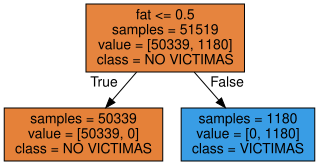

In [17]:
graphviz.Source(dot_graph)

In [ ]:
pip install lime

In [16]:
print("Feature importances:\n{}".format(tree.feature_importances_))

Feature importances:
[0.00996489 0.         0.         0.         0.00087148 0.10477625
 0.8468396  0.00407882 0.         0.         0.         0.00228126
 0.0185713  0.0037444  0.         0.         0.00548535 0.
 0.00338665 0.        ]


In [17]:
import matplotlib.pyplot as plt
import numpy as np

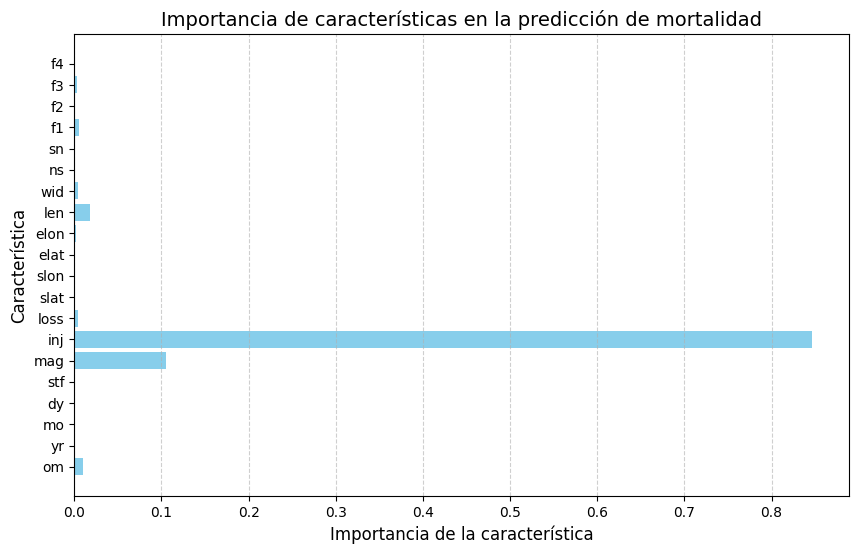

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importances_tornados(model, feature_names):
    """
    Visualiza la importancia de las características para un modelo entrenado.
    
    Parámetros:
    -----------
    model : modelo entrenado (ej: DecisionTreeClassifier, RandomForest)
    feature_names : list
        Nombres de las características usadas en el modelo.
    """
    n_features = len(feature_names)
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(n_features), model.feature_importances_, align='center', color='skyblue')
    plt.yticks(np.arange(n_features), feature_names)
    plt.xlabel("Importancia de la característica", fontsize=12)
    plt.ylabel("Característica", fontsize=12)
    plt.title("Importancia de características en la predicción de mortalidad", fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

# Uso de la función con tu modelo y datos:
feature_names = ['om', 'yr', 'mo', 'dy', 'stf', 'mag', 'inj', 'loss', 
                 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 
                 'f1', 'f2', 'f3', 'f4']  # Asegúrate de que coincida con X_train.columns

plot_feature_importances_tornados(tree, feature_names)

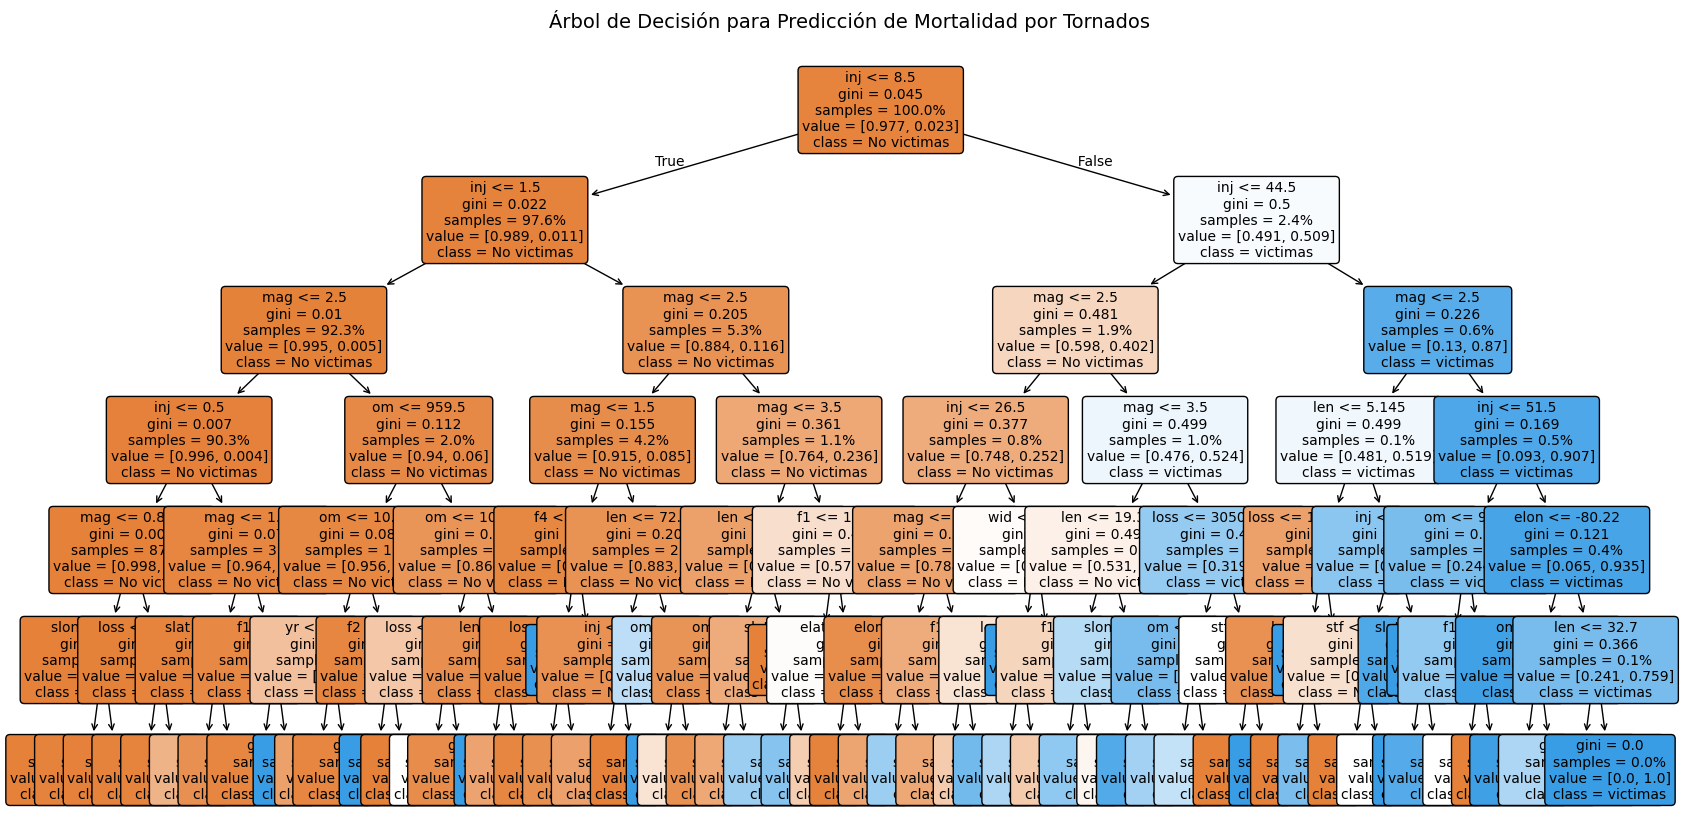

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np

# 1. Entrenar un árbol de decisión (como ya lo tienes)
tree = DecisionTreeClassifier(max_depth=6, random_state=42)  # Limitar profundidad para visualización
tree.fit(X_train, y_train)

# 2. Visualizar el árbol
plt.figure(figsize=(20, 10))
plot_tree(tree, 
          feature_names=X_train.columns.tolist(),  # Nombres de tus características
          class_names=['No victimas', 'victimas'],  # Nombres de tus clases
          filled=True, 
          rounded=True, 
          proportion=True,
          fontsize=10)
plt.title("Árbol de Decisión para Predicción de Mortalidad por Tornados", pad=20, fontsize=14)
plt.show()

In [ ]:
pip install mglearn

Columnas disponibles: ['om', 'yr', 'mo', 'dy', 'date', 'time', 'tz', 'datetime_utc', 'st', 'stf', 'mag', 'inj', 'fat', 'loss', 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 'f1', 'f2', 'f3', 'f4', 'fc']


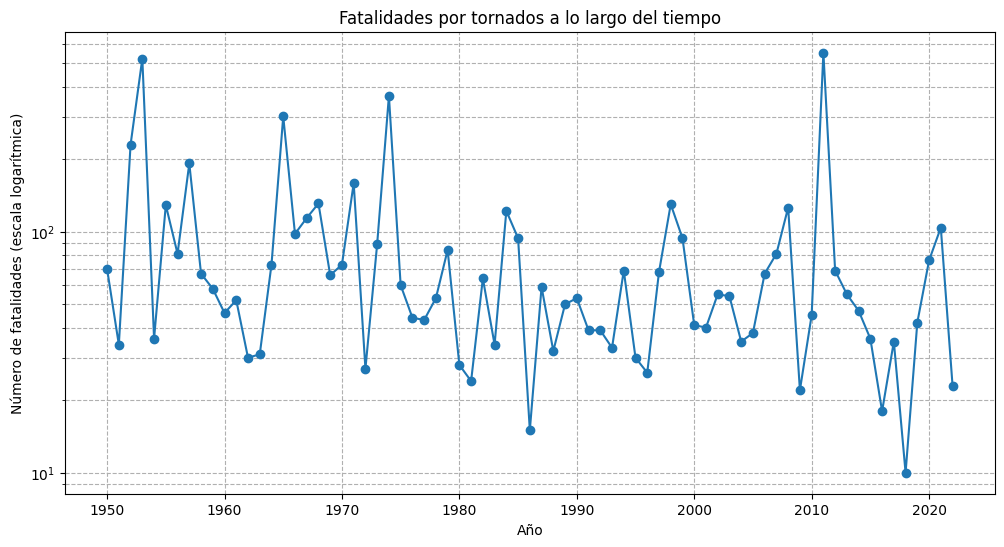

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos
ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta) 

# 2. Verificar las columnas disponibles
print("Columnas disponibles:", df.columns.tolist())

# 3. Convertir la columna de fechas a datetime (si existe)
# Asumo que tienes una columna 'datetime_utc' o similar
if 'datetime_utc' in df.columns:
    df['datetime_utc'] = pd.to_datetime(df['datetime_utc'])
    df['year'] = df['datetime_utc'].dt.year  # Extraer año si necesitas agrupar por año

# 4. Gráfico de fatalidades a lo largo del tiempo (versión corregida)
plt.figure(figsize=(12, 6))

# Opción 1: Si tienes columnas 'year' y 'fat' (fatalidades)
if 'year' in df.columns and 'fat' in df.columns:
    # Agrupar fatalidades por año
    fatalidades_por_año = df.groupby('year')['fat'].sum()
    
    plt.semilogy(fatalidades_por_año.index, fatalidades_por_año.values, 'o-')
    plt.xlabel("Año")
    plt.ylabel("Número de fatalidades (escala logarítmica)")
    plt.title("Fatalidades por tornados a lo largo del tiempo")
    plt.grid(True, which="both", ls="--")

# Opción 2: Si tienes fechas exactas
elif 'datetime_utc' in df.columns and 'fat' in df.columns:
    plt.semilogy(df['datetime_utc'], df['fat'], 'o', alpha=0.5)
    plt.xlabel("Fecha")
    plt.ylabel("Número de fatalidades (escala logarítmica)")
    plt.title("Fatalidades por tornados a lo largo del tiempo")
    plt.grid(True, which="both", ls="--")

else:
    print("No se encontraron las columnas necesarias ('datetime_utc' o 'fat')")

plt.show()

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

In [26]:
import pandas as pd

# Asumiendo que tu DataFrame se llama df y tiene una columna de fecha llamada 'date'
# Si tu columna tiene otro nombre (ej: 'datetime_utc'), cámbialo en el código

# 1. Convertir la columna de fecha a tipo datetime (si no lo está)
df['date'] = pd.to_datetime(df['date'])  # Cambia 'date' por tu columna real

# 2. Definir el año de corte (ej: entrenar con datos antes del 2010 y test después)
corte_year = 2010

# 3. Dividir los datos
train = df[df['date'].dt.year < corte_year]
test = df[df['date'].dt.year >= corte_year]

# 4. Verificación
print(f"Entrenamiento: {train.shape[0]} registros ({train['date'].min().year}-{train['date'].max().year})")
print(f"Prueba: {test.shape[0]} registros ({test['date'].min().year}-{test['date'].max().year})")

Entrenamiento: 53228 registros (1950-2009)
Prueba: 15465 registros (2010-2022)


In [27]:
# Dividir considerando fatalidades ('fat')
corte_year = 2010
train = df[df['date'].dt.year < corte_year]
test = df[df['date'].dt.year >= corte_year]

# Análisis comparativo
print("\nFatalidades promedio:")
print(f"Entrenamiento: {train['fat'].mean():.2f} por tornado")
print(f"Prueba: {test['fat'].mean():.2f} por tornado")


Fatalidades promedio:
Entrenamiento: 0.09 por tornado
Prueba: 0.07 por tornado


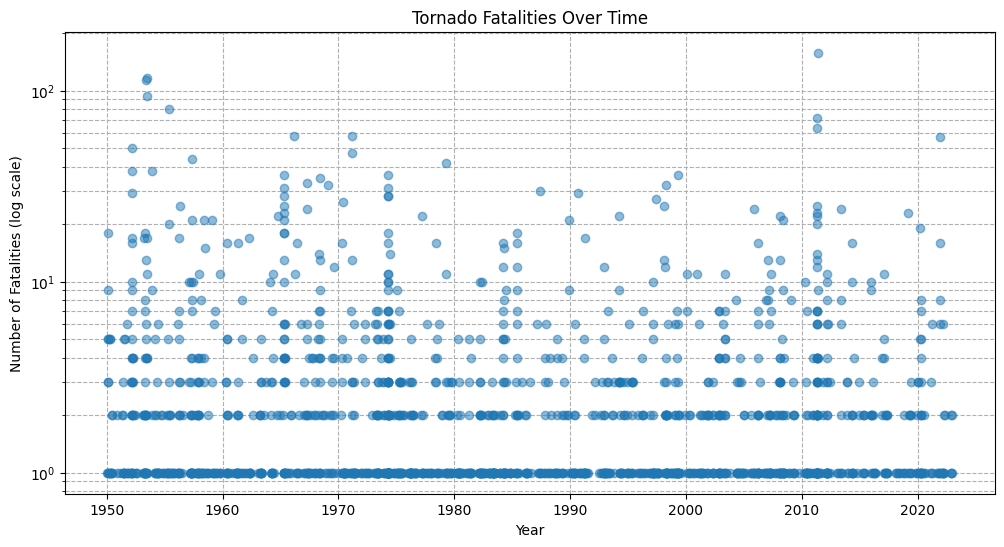

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your tornado data
tornado_data = pd.read_csv(ruta)

# 2. Convert date column to datetime
tornado_data['date'] = pd.to_datetime(tornado_data['date'])

# 3. Verify and clean numerical columns (like fatalities)
# Convert string numbers to numeric, coercing errors to NaN
tornado_data['fat'] = pd.to_numeric(tornado_data['fat'], errors='coerce')

# 4. Handle zeros/negative values before log transform
# Add small constant to avoid log(0)
tornado_data['log_fat'] = np.log(tornado_data['fat'] + 1e-6)  # 1e-6 avoids log(0)

# 5. Now create the semi-log plot correctly
plt.figure(figsize=(12, 6))
plt.semilogy(tornado_data['date'], tornado_data['fat'], 'o', alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Number of Fatalities (log scale)")
plt.title("Tornado Fatalities Over Time")
plt.grid(True, which="both", ls="--")
plt.show()

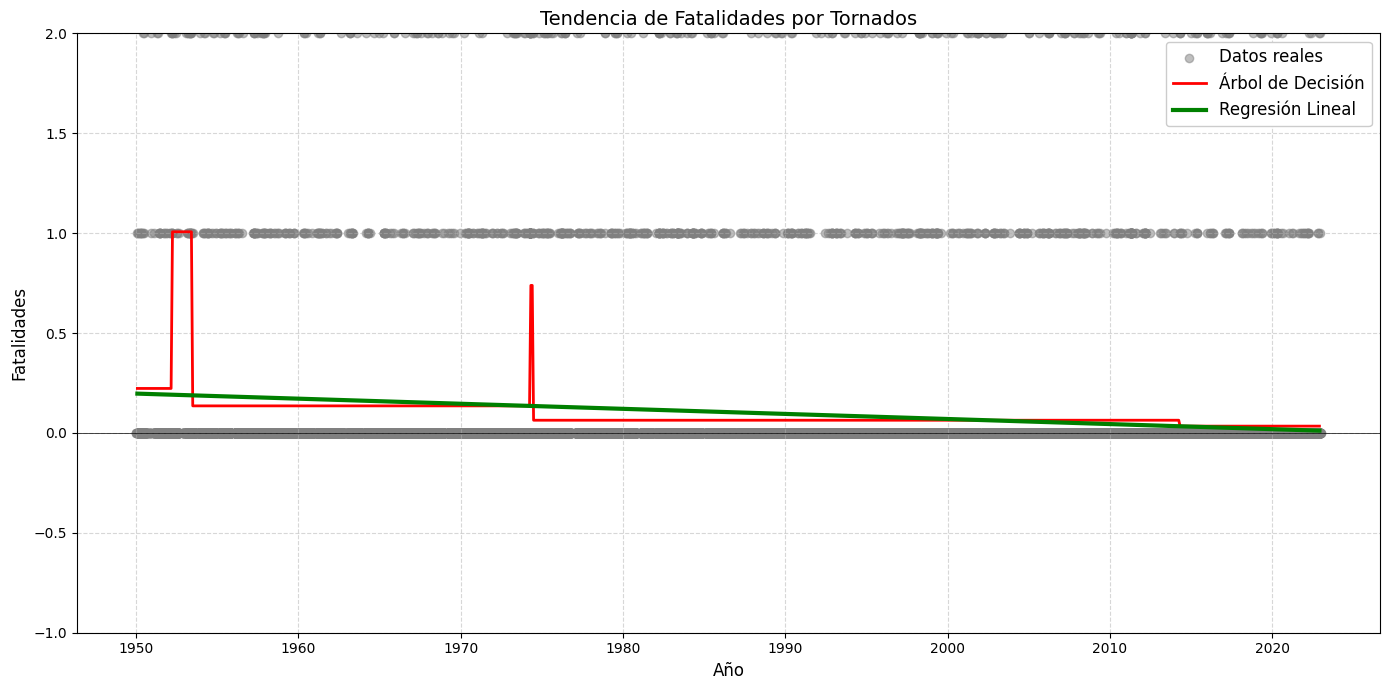

In [29]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Cargar y preparar datos
df = pd.read_csv(ruta)
df['date'] = pd.to_datetime(df['date'])
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

# Variables para el modelo
X = df[['days_since_start']]
y = df['fat'].fillna(0)  # Asumiendo que 'fat' son fatalidades

# Entrenar modelos
tree = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X, y)
linear = LinearRegression().fit(X, y)

# Crear rango de predicción
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='M')
X_pred = pd.DataFrame({'days_since_start': [(d - df['date'].min()).days for d in date_range]})

# Predicciones
df_pred = pd.DataFrame({
    'date': date_range,
    'tree_pred': tree.predict(X_pred),
    'linear_pred': linear.predict(X_pred)
})

# Configuración del gráfico con tus requisitos
plt.figure(figsize=(14, 7))

# 1. Datos reales
plt.scatter(df['date'], y, alpha=0.5, label='Datos reales', color='gray')

# 2. Línea de Árbol de Decisión (roja)
plt.plot(df_pred['date'], df_pred['tree_pred'], 'r-', lw=2, label='Árbol de Decisión')

# 3. Línea de Regresión Lineal (verde)
plt.plot(df_pred['date'], df_pred['linear_pred'], 'g-', lw=3, label='Regresión Lineal')  # Verde sólido

# Configuración de ejes
plt.ylim(-1, 2)  # Rango del eje Y fijo de -5 a 10
plt.xlabel('Año', fontsize=12)
plt.ylabel('Fatalidades', fontsize=12)
plt.title('Tendencia de Fatalidades por Tornados', fontsize=14)

# Elementos adicionales
plt.legend(fontsize=12, framealpha=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # Línea en y=0

# Ajustar márgenes
plt.tight_layout()
plt.show()